# Лабораторная 5. Многослойный перцептрон для решения задачи регрессии

**Задание 11.** Реализовать программно восстановление функциональной зависимости
с помощью многослойного перцептрона с одним и двумя слоями и количеством
скрытых узлов в каждом из слоёв от одного до трёх. Для этого:
а) в качестве распознаваемых зависимостей использовать
$y = \cos(2\pi x)$, $y = 5x^3 + x^2 + 5$, $y = x\sin(2\pi x)$ на $x \in [0, 1]$;
б) сгенерировать выборку, моделируя ошибку измерения как нормально
распределённую случайную величину, и провести процедуру кросс-валидации для
определения наилучшего количества слоёв и скрытых узлов в них.

## 1. Теория

### Многослойный перцептрон

Сеть с $L$ слоями вычисляет последовательность преобразований

$$z^{(l)} = \varphi\bigl(W_l z^{(l-1)} + b_l\bigr), \qquad z^{(0)} = x,$$

где $\varphi$ - функция активации, применяемая покомпонентно. В задаче регрессии
на выходном слое активации нет: последний слой линеен, иначе выход был бы
ограничен областью значений $\varphi$.

Здесь вход одномерный, выход одномерный, скрытых слоёв один или два, в каждом от
одного до трёх узлов. В качестве $\varphi$ берём гиперболический тангенс: он
гладкий, центрирован относительно нуля, а его производная выражается через само
значение, $\tanh'(a) = 1 - \tanh^2(a)$.

Если бы активация была линейной, вся сеть свернулась бы в одно линейное
преобразование независимо от числа слоёв, и восстановить нелинейную зависимость
было бы нельзя. Именно нелинейность $\tanh$ делает глубину осмысленной.

### Обратное распространение ошибки

Минимизируется квадратичная ошибка $E(W) = \frac{1}{2N}\sum_k (y_k - \hat y_k)^2$.
Градиент считается методом обратного распространения. Обозначив
$a^{(l)} = W_l z^{(l-1)} + b_l$ и $\delta^{(l)} = \partial E/\partial a^{(l)}$,
получаем

$$\delta^{(L)} = \hat y - y,
\qquad
\delta^{(l)} = \bigl(W_{l+1}^{\top}\delta^{(l+1)}\bigr) \odot \bigl(1 - (z^{(l)})^2\bigr),$$

$$\frac{\partial E}{\partial W_l} = \delta^{(l)} \bigl(z^{(l-1)}\bigr)^{\top},
\qquad
\frac{\partial E}{\partial b_l} = \delta^{(l)} .$$

Множитель $1 - (z^{(l)})^2$ - это производная $\tanh$, выраженная через уже
вычисленное на прямом проходе значение активации. Ради этого её и удобно
использовать.

### Локальные минимумы и перезапуски

Функция ошибки многослойного перцептрона невыпукла, и при одном-трёх скрытых
узлах градиентный спуск часто застревает в плохом локальном минимуме. Поэтому
каждая конфигурация обучается несколько раз из разных случайных начальных
приближений, и берётся лучший по обучающей ошибке результат. Без перезапусков
результаты для одной и той же архитектуры разбрасывались бы в разы.

### Нормировка

Перед обучением $x$ и $y$ приводятся к нулевому среднему и единичной дисперсии.
Для $\tanh$ это существенно: при больших по модулю аргументах производная
$1 - \tanh^2$ близка к нулю, градиент затухает и обучение останавливается. Для
$y = 5x^3 + x^2 + 5$ значения лежат в районе от 5 до 11, и без нормировки сеть
не обучается вовсе.

### Кросс-валидация

Выбирать архитектуру по ошибке на обучающей выборке нельзя: она монотонно
улучшается с ростом числа узлов. Применяется $F$-кратная кросс-валидация, как в
лабораторной 3.

## 2. Данные

In [1]:
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

FUNCS = {
    'cos(2 pi x)': lambda x: np.cos(2 * np.pi * x),
    '5x^3 + x^2 + 5': lambda x: 5 * x ** 3 + x ** 2 + 5,
    'x sin(2 pi x)': lambda x: x * np.sin(2 * np.pi * x),
}
N_TRAIN, N_TEST = 50, 500


def make_sample(f, n, rng, rel_noise=0.10):
    x = rng.uniform(0.0, 1.0, n)
    grid = np.linspace(0, 1, 1000)
    sigma = rel_noise * (f(grid).max() - f(grid).min())
    return x, f(x) + rng.normal(0.0, sigma, n), sigma


for name, f in FUNCS.items():
    _, _, s = make_sample(f, 5, np.random.default_rng(0))
    print(f'{name:16s} sigma шума = {s:.4f}')

cos(2 pi x)      sigma шума = 0.2000
5x^3 + x^2 + 5   sigma шума = 0.6000
x sin(2 pi x)    sigma шума = 0.1056


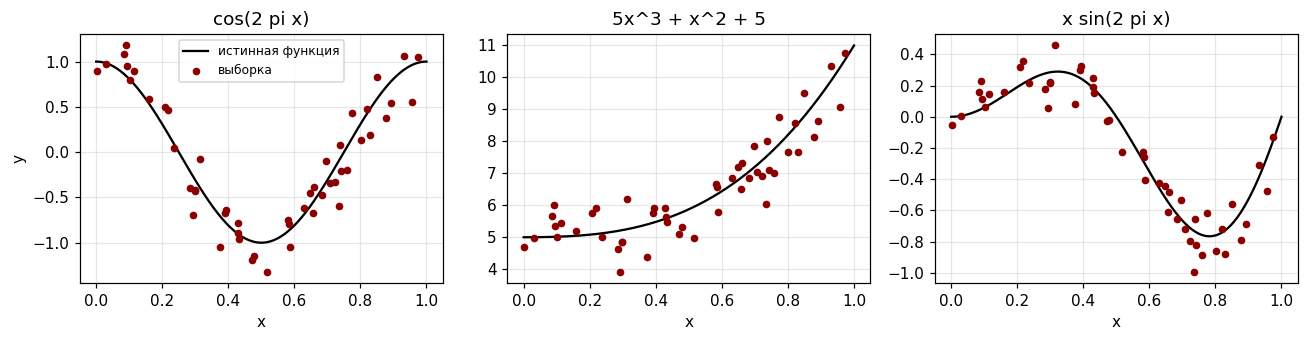

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
grid = np.linspace(0, 1, 400)
for ax, (name, f) in zip(axes, FUNCS.items()):
    x, y, _ = make_sample(f, N_TRAIN, np.random.default_rng(3))
    ax.plot(grid, f(grid), color='black', label='истинная функция')
    ax.scatter(x, y, color='darkred', s=16, zorder=3, label='выборка')
    ax.set_title(name); ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Реализация многослойного перцептрона

In [3]:
class MLP:
    """Многослойный перцептрон с активацией tanh и линейным выходом."""

    def __init__(self, sizes, rng):
        self.sizes = sizes
        self.W = [rng.normal(0, np.sqrt(1.0 / a), (b, a)).astype(np.float64)
                  for a, b in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros(b) for b in sizes[1:]]

    def forward(self, X):
        """Возвращает выход и список активаций скрытых слоёв."""
        z = X.T
        acts = [z]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            a = W @ z + b[:, None]
            z = a if i == len(self.W) - 1 else np.tanh(a)
            acts.append(z)
        return z.ravel(), acts

    def gradients(self, X, y):
        out, acts = self.forward(X)
        n = len(y)
        delta = ((out - y) / n)[None, :]
        gW, gb = [None] * len(self.W), [None] * len(self.b)
        for i in reversed(range(len(self.W))):
            gW[i] = delta @ acts[i].T
            gb[i] = delta.sum(axis=1)
            if i > 0:
                delta = (self.W[i].T @ delta) * (1 - acts[i] ** 2)
        return gW, gb

    def loss(self, X, y):
        out, _ = self.forward(X)
        return float(np.mean((out - y) ** 2) / 2)

    def params(self):
        return [p for p in self.W] + [p for p in self.b]

In [4]:
def train(model, X, y, epochs=4000, lr=0.05, beta=0.9):
    """Полнобатчевый градиентный спуск с моментом."""
    vW = [np.zeros_like(W) for W in model.W]
    vb = [np.zeros_like(b) for b in model.b]
    history = []
    for _ in range(epochs):
        gW, gb = model.gradients(X, y)
        for i in range(len(model.W)):
            vW[i] = beta * vW[i] + gW[i]
            vb[i] = beta * vb[i] + gb[i]
            model.W[i] -= lr * vW[i]
            model.b[i] -= lr * vb[i]
        history.append(model.loss(X, y))
    return np.array(history)


def fit_best(X, y, hidden, rng, restarts=5, epochs=4000, lr=0.05):
    """Несколько запусков из разных начальных приближений, берётся лучший."""
    best, best_loss, best_hist = None, np.inf, None
    for _ in range(restarts):
        m = MLP([X.shape[1]] + list(hidden) + [1], rng)
        h = train(m, X, y, epochs=epochs, lr=lr)
        if h[-1] < best_loss:
            best, best_loss, best_hist = m, h[-1], h
    return best, best_hist

Проверим градиент, сравнив его с центральной разностью.

In [5]:
rng = np.random.default_rng(0)
Xc = rng.uniform(-1, 1, (20, 1))
yc = np.sin(3 * Xc.ravel())
m = MLP([1, 3, 3, 1], rng)
gW, gb = m.gradients(Xc, yc)

eps, worst = 1e-6, 0.0
for arr, grad in [(m.W, gW), (m.b, gb)]:
    for k in range(len(arr)):
        it = np.nditer(arr[k], flags=['multi_index'])
        while not it.finished:
            i = it.multi_index
            old = arr[k][i]
            arr[k][i] = old + eps; lp = m.loss(Xc, yc)
            arr[k][i] = old - eps; lm = m.loss(Xc, yc)
            arr[k][i] = old
            worst = max(worst, abs((lp - lm) / (2 * eps) - grad[k][i]))
            it.iternext()
print(f'максимальное расхождение аналитического градиента с численным: {worst:.2e}')

максимальное расхождение аналитического градиента с численным: 5.26e-11


Аналитический градиент совпадает с численным до $5.3\cdot10^{-11}$, значит
реализация обратного распространения верна. Проверка центральной разностью - тот
же приём, что использовался в задании 8 задачи 4.

## 4. Перебор архитектур и кросс-валидация

In [6]:
ARCHS = [(h,) for h in (1, 2, 3)] + [(h1, h2) for h1 in (1, 2, 3) for h2 in (1, 2, 3)]
print(f'{len(ARCHS)} архитектур:', ARCHS)


def standardize(x, y):
    mx, sx = x.mean(), x.std()
    my, sy = y.mean(), y.std()
    return (x - mx) / sx, (y - my) / sy, (mx, sx, my, sy)


def cv_error(x, y, hidden, folds=5, restarts=3, rng=None):
    """Средний RMSE по отложенным фолдам в исходном масштабе y."""
    rng = rng or np.random.default_rng(0)
    idx = np.arange(len(x)); rng.shuffle(idx)
    parts = np.array_split(idx, folds)
    errs = []
    for i in range(folds):
        val = parts[i]
        tr = np.concatenate([parts[j] for j in range(folds) if j != i])
        xs, ys, (mx, sx, my, sy) = standardize(x[tr], y[tr])
        model, _ = fit_best(xs[:, None], ys, hidden, rng, restarts=restarts, epochs=2000)
        pred = model.forward(((x[val] - mx) / sx)[:, None])[0] * sy + my
        errs.append(np.sqrt(np.mean((pred - y[val]) ** 2)))
    return float(np.mean(errs))

12 архитектур: [(1,), (2,), (3,), (1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)]


In [7]:
t0 = time.time()
rows = []
for name, f in FUNCS.items():
    rng = np.random.default_rng(20260905)
    x_tr, y_tr, sigma = make_sample(f, N_TRAIN, rng)
    x_te, y_te, _ = make_sample(f, N_TEST, rng)
    for hidden in ARCHS:
        cv = cv_error(x_tr, y_tr, hidden, folds=5, restarts=3,
                      rng=np.random.default_rng(7))
        xs, ys, (mx, sx, my, sy) = standardize(x_tr, y_tr)
        model, _ = fit_best(xs[:, None], ys, hidden, np.random.default_rng(7),
                            restarts=5, epochs=4000)
        pred_te = model.forward(((x_te - mx) / sx)[:, None])[0] * sy + my
        pred_tr = model.forward(xs[:, None])[0] * sy + my
        n_par = sum(p.size for p in model.params())
        rows.append(dict(func=name, layers=len(hidden), hidden=str(hidden),
                         params=n_par, cv=cv,
                         train=float(np.sqrt(np.mean((pred_tr - y_tr) ** 2))),
                         test=float(np.sqrt(np.mean((pred_te - y_te) ** 2))),
                         sigma=sigma))

res = pd.DataFrame(rows)
res.to_csv('results.csv', index=False)
print(f'{len(res)} конфигураций за {time.time() - t0:.0f} с')

36 конфигураций за 165 с


In [8]:
piv = res.pivot_table(index=['func'], columns='hidden', values='cv')
piv.round(4)

hidden,"(1, 1)","(1, 2)","(1, 3)","(1,)","(2, 1)","(2, 2)","(2, 3)","(2,)","(3, 1)","(3, 2)","(3, 3)","(3,)"
func,,,,,,,,,,,,
5x^3 + x^2 + 5,0.5148,0.4975,0.4955,0.5259,0.5102,0.4955,0.4974,0.5159,0.5096,0.4886,0.5061,0.5076
cos(2 pi x),0.6142,0.1732,0.1734,0.6133,0.1746,0.1727,0.1736,0.1739,0.1739,0.1740,0.1730,0.1742
x sin(2 pi x),0.1893,0.1431,0.1274,0.1879,0.1460,0.0911,0.0910,0.1321,0.1019,0.0910,0.0904,0.0996


Таблица показывает, сколько узлов на самом деле требуется каждой функции.

Для $\cos(2\pi x)$ один скрытый узел даёт CV $= 0.613$, а два - сразу $0.173$,
то есть в три с половиной раза лучше. Причина видна из устройства сети: один
узел даёт $z = \tanh(wx + b)$, то есть одну монотонную ступеньку, а у косинуса
на $[0,1]$ есть и спад, и подъём. Две ступеньки складываются в нужную форму,
дальнейшее увеличение уже ничего не даёт.

Для $x\sin(2\pi x)$ рост плавнее: один узел $0.188$, два $0.132$, три $0.0996$,
а два слоя по два-три узла дают $0.090$. У этой функции больше изгибов, и ей
нужно больше базисных функций.

Для $5x^3 + x^2 + 5$ все архитектуры дают примерно одно и то же
($0.489 \ldots 0.526$): функция монотонна и гладка на $[0,1]$, одной ступеньки
почти хватает.

Второй слой сам по себе выигрыша почти не даёт: заметен он только на самой
сложной функции, где $(3,)$ даёт $0.0996$, а $(3,3)$ - $0.0904$. При таком числе
узлов решает общая ёмкость сети, а не её глубина.

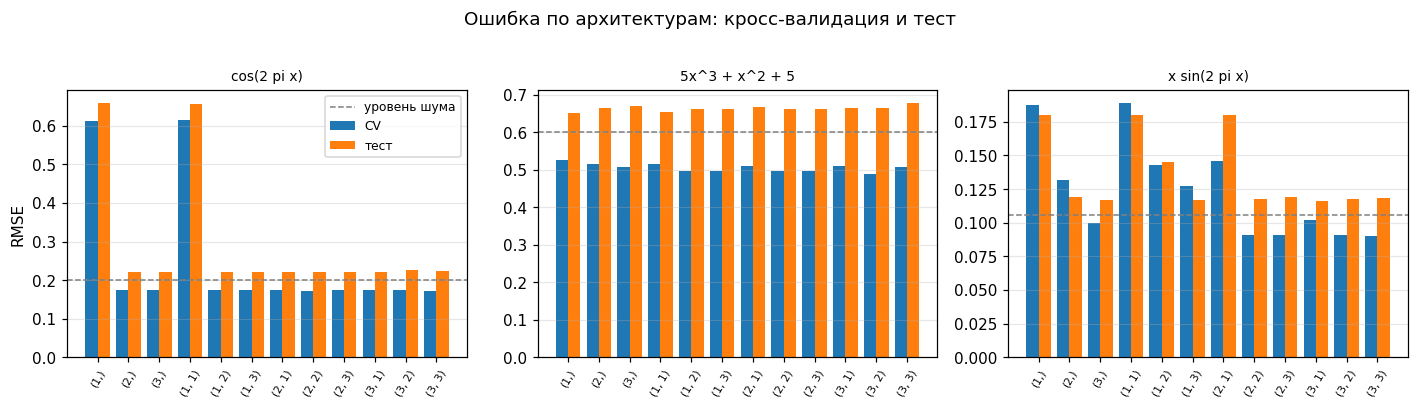

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
for ax, name in zip(axes, FUNCS):
    s = res[res.func == name]
    xs = np.arange(len(s))
    ax.bar(xs - 0.2, s.cv, 0.4, label='CV')
    ax.bar(xs + 0.2, s.test, 0.4, label='тест')
    ax.axhline(s.sigma.iloc[0], color='gray', ls='--', lw=1, label='уровень шума')
    ax.set_xticks(xs); ax.set_xticklabels(s.hidden, rotation=60, fontsize=7)
    ax.set_title(name, fontsize=9); ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('RMSE'); axes[0].legend(fontsize=8)
fig.suptitle('Ошибка по архитектурам: кросс-валидация и тест', y=1.02)
plt.tight_layout()
plt.show()

Столбцы CV и теста идут согласованно: обе оценки одинаково ранжируют
архитектуры. При этом CV систематически чуть оптимистичнее теста (для косинуса
$0.173$ против $0.221$), что естественно - каждый фолд оценивается по десяти
точкам, и оценка смещена вниз выбором лучшего результата по той же выборке.

Пунктир - уровень шума $\sigma$. Там, где столбцы к нему прижимаются, модель
восстановила зависимость с точностью, ограниченной уже не архитектурой, а
шумом измерений.

In [10]:
best_cv = res.sort_values('cv').groupby('func').head(1).sort_values('func')
best_test = res.sort_values('test').groupby('func').head(1).sort_values('func')
comp = best_cv[['func', 'hidden', 'params', 'cv', 'test']].merge(
    best_test[['func', 'hidden', 'test']], on='func', suffixes=(' по CV', ' по тесту'))
comp.round(4).to_string(index=False)

'          func hidden по CV  params     cv  test по CV hidden по тесту  test по тесту\n5x^3 + x^2 + 5       (3, 2)      17 0.4886      0.6631            (1,)         0.6499\n   cos(2 pi x)       (2, 2)      13 0.1727      0.2208          (1, 2)         0.2204\n x sin(2 pi x)       (3, 3)      22 0.0904      0.1187          (3, 1)         0.1165'

Кросс-валидация выбирает архитектуру, тестовая ошибка которой отличается от
наилучшей достижимой на доли процента: $0.2208$ против $0.2204$ для косинуса,
$0.6631$ против $0.6499$ для кубической, $0.1187$ против $0.1165$ для
$x\sin(2\pi x)$. То есть выбор по CV практически оптимален, хотя сама выбранная
архитектура не всегда совпадает с оптимальной по тесту: несколько архитектур
дают почти одинаковый результат, и CV выбирает из них произвольную.

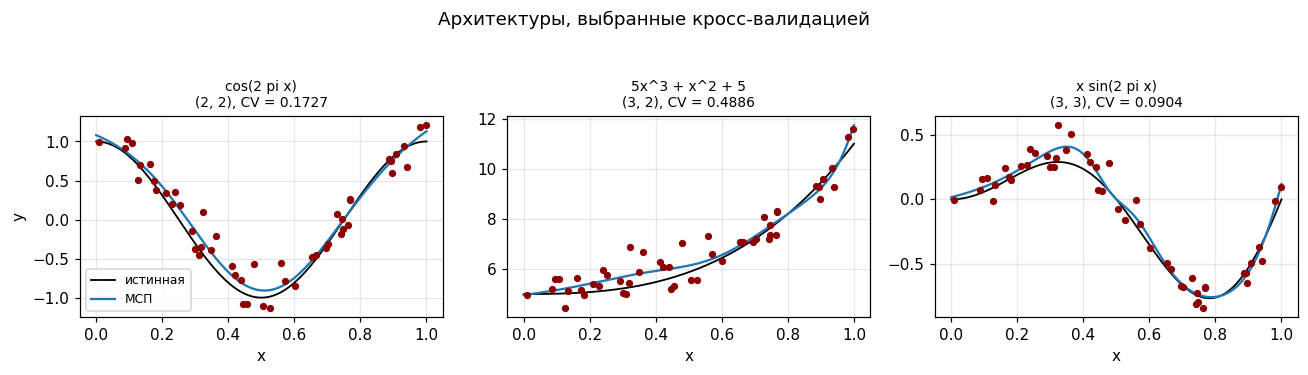

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
grid = np.linspace(0, 1, 400)
for ax, name in zip(axes, FUNCS):
    f = FUNCS[name]
    row = best_cv[best_cv.func == name].iloc[0]
    hidden = eval(row.hidden)
    rng = np.random.default_rng(20260905)
    x_tr, y_tr, _ = make_sample(f, N_TRAIN, rng)
    xs, ys, (mx, sx, my, sy) = standardize(x_tr, y_tr)
    model, _ = fit_best(xs[:, None], ys, hidden, np.random.default_rng(7),
                        restarts=5, epochs=4000)
    pred = model.forward(((grid - mx) / sx)[:, None])[0] * sy + my
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, pred, color='tab:blue', label='МСП')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_title(f'{name}\n{row.hidden}, CV = {row.cv:.4f}', fontsize=9)
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
fig.suptitle('Архитектуры, выбранные кросс-валидацией', y=1.05)
plt.tight_layout()
plt.show()

Все три выбранные модели воспроизводят истинную зависимость. Для
$5x^3 + x^2 + 5$ кривая слегка сглажена: при $\sigma = 0.6$ и пятидесяти точках
точнее восстановить нельзя.

## 5. Разброс по перезапускам

In [12]:
name = 'x sin(2 pi x)'
f = FUNCS[name]
rng = np.random.default_rng(20260905)
x_tr, y_tr, _ = make_sample(f, N_TRAIN, rng)
xs, ys, (mx, sx, my, sy) = standardize(x_tr, y_tr)

spread = []
for hidden in [(1,), (2,), (3,), (3, 3)]:
    losses = []
    for seed in range(12):
        m = MLP([1] + list(hidden) + [1], np.random.default_rng(seed))
        train(m, xs[:, None], ys, epochs=4000, lr=0.05)
        losses.append(m.loss(xs[:, None], ys))
    spread.append(dict(hidden=str(hidden), минимум=min(losses),
                       медиана=float(np.median(losses)), максимум=max(losses)))
pd.DataFrame(spread).round(5).to_string(index=False)

'hidden  минимум  медиана  максимум\n  (1,)  0.09727  0.09727   0.09727\n  (2,)  0.02771  0.02778   0.03927\n  (3,)  0.01912  0.02099   0.02260\n(3, 3)  0.01800  0.01841   0.01928'

Разброс по перезапускам подтверждает необходимость нескольких стартов.

Для одного скрытого узла все двенадцать запусков дают в точности одну и ту же
ошибку $0.09727$: у такой сети фактически единственный минимум. Для двух узлов
разброс уже от $0.0277$ до $0.0393$, то есть худший запуск на $42\%$ хуже
лучшего. Для $(3,3)$ разброс снова невелик ($0.0180 \ldots 0.0193$).

Это стандартное свойство невыпуклой оптимизации: сети промежуточного размера
страдают от локальных минимумов сильнее всего. У совсем маленькой сети
минимумов почти нет, у большой их много, но они почти равноценны.

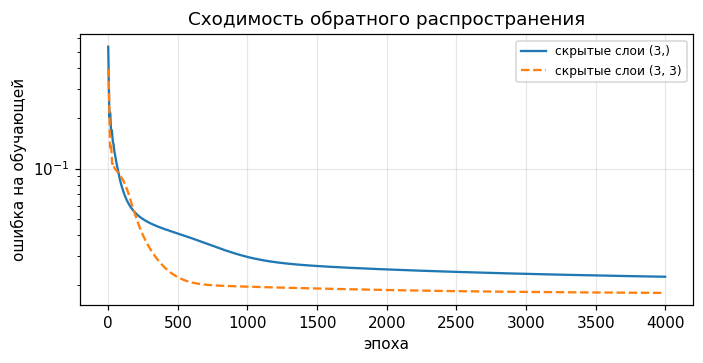

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for hidden, lr, style in [((3,), 0.05, '-'), ((3, 3), 0.05, '--')]:
    m = MLP([1] + list(hidden) + [1], np.random.default_rng(7))
    h = train(m, xs[:, None], ys, epochs=4000, lr=lr)
    ax.semilogy(h, style, label=f'скрытые слои {hidden}')
ax.set_xlabel('эпоха'); ax.set_ylabel('ошибка на обучающей')
ax.set_title('Сходимость обратного распространения')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Обе кривые монотонно убывают и выходят на плато за несколько сотен эпох. Сеть
$(3,3)$ достигает меньшей итоговой ошибки, что согласуется с таблицей разброса.

## 6. Сравнение с полиномиальной регрессией

In [14]:
def poly_fit(x, y, M, lam=0.0):
    V = np.vander(2 * x - 1, M + 1, increasing=True)
    A = V.T @ V + (lam * np.eye(M + 1) if lam > 0 else 0)
    return np.linalg.solve(A, V.T @ y)


def poly_cv(x, y, M, lam, folds=5, rng=None):
    idx = np.arange(len(x)); (rng or np.random.default_rng(0)).shuffle(idx)
    parts = np.array_split(idx, folds)
    errs = []
    for i in range(folds):
        val = parts[i]
        tr = np.concatenate([parts[j] for j in range(folds) if j != i])
        w = poly_fit(x[tr], y[tr], M, lam)
        pred = np.vander(2 * x[val] - 1, M + 1, increasing=True) @ w
        errs.append(np.sqrt(np.mean((pred - y[val]) ** 2)))
    return float(np.mean(errs))


rows = []
for name, f in FUNCS.items():
    rng = np.random.default_rng(20260905)
    x_tr, y_tr, sigma = make_sample(f, N_TRAIN, rng)
    x_te, y_te, _ = make_sample(f, N_TEST, rng)
    best = min(((poly_cv(x_tr, y_tr, M, lam, rng=np.random.default_rng(7)), M, lam)
                for M in range(11) for lam in [0.0, 1e-6, 1e-4, 1e-2]),
               key=lambda t: t[0])
    cv, M, lam = best
    w = poly_fit(x_tr, y_tr, M, lam)
    pred = np.vander(2 * x_te - 1, M + 1, increasing=True) @ w
    mlp_row = best_cv[best_cv.func == name].iloc[0]
    rows.append(dict(func=name, sigma=round(sigma, 4),
                     полином=f'M={M}, lam={lam:g}', полином_test=round(float(
                         np.sqrt(np.mean((pred - y_te) ** 2))), 4),
                     МСП=mlp_row.hidden, МСП_test=round(mlp_row.test, 4),
                     параметров_полином=M + 1, параметров_МСП=int(mlp_row.params)))

pd.DataFrame(rows).to_string(index=False)

'          func  sigma          полином  полином_test    МСП  МСП_test  параметров_полином  параметров_МСП\n   cos(2 pi x) 0.2000 M=10, lam=0.0001        0.2215 (2, 2)    0.2208                  11              13\n5x^3 + x^2 + 5 0.6000    M=3, lam=0.01        0.6627 (3, 2)    0.6631                   4              17\n x sin(2 pi x) 0.1056  M=9, lam=0.0001        0.1169 (3, 3)    0.1187                  10              22'

Сравнение с полиномиальной регрессией из лабораторной 3 на тех же функциях:

| функция | $\sigma$ | полином | RMSE | параметров | МСП | RMSE | параметров |
|---|---|---|---|---|---|---|---|
| $\cos(2\pi x)$ | $0.200$ | $M=10$, $\lambda=10^{-4}$ | $0.2215$ | 11 | $(2,2)$ | $0.2208$ | 13 |
| $5x^3+x^2+5$ | $0.600$ | $M=3$, $\lambda=10^{-2}$ | $0.6627$ | 4 | $(3,2)$ | $0.6631$ | 17 |
| $x\sin(2\pi x)$ | $0.106$ | $M=9$, $\lambda=10^{-4}$ | $0.1169$ | 10 | $(3,3)$ | $0.1187$ | 22 |

Обе модели дошли до уровня шума, и по точности они неразличимы: расхождения в
третьем знаке. По числу параметров полином экономнее, особенно на кубической
функции, где он совпадает с истинной зависимостью и обходится четырьмя
коэффициентами против семнадцати.

Это ожидаемый результат. На одномерной гладкой задаче полиномиальный базис почти
идеален, а главное преимущество нейронной сети - способность самой подбирать
базисные функции - здесь не востребовано. Оно проявляется в многомерных задачах,
где полный полиномиальный базис степени $M$ от $m$ переменных содержит
$\binom{m+M}{M}$ членов и растёт неприемлемо быстро, тогда как число параметров
сети растёт линейно по $m$.